<a href="https://colab.research.google.com/github/bhavana-ux618/thiranex_internship/blob/main/Thiranex_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project statement:**

**Data Cleaning & Visualization Project:**

Work on a raw dataset to clean, process, and visualize insights.

**Key Features:**

* Handle missing values, outliers, and duplicates
* Use Python libraries like Pandas, Matplotlib, or Seaborn
* Create dashboards or visual reports of key findings

**Expected Outcome:**

Learn data preprocessing, visualization, and storytelling with data

# **Project Scenario:**

**Title:** Superstore Sales Analysis

**Objective:** Understand customer buying patterns, identify unprofitable sales, and visualize trends.

**Step 1: Setup & Generate "Messy" Data:**

First, we simulate a raw dataset that contains common errors: missing values, duplicate rows, text inconsistencies, and outliers (negative sales or extremely high discounts).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. Create Raw Data (Simulating a messy CSV) ---
data = {
    'Order_ID': ['ORD-001', 'ORD-002', 'ORD-003', 'ORD-001', 'ORD-004', 'ORD-005', 'ORD-006', 'ORD-007'],
    'Order_Date': ['2023-01-01', '2023-01-05', '2023-01-10', '2023-01-01', '2023-02-15', '2023-02-20', None, '2023-03-05'],
    'Category': ['Furniture', 'Furniture', 'Electronics', 'Electronics', 'Office', 'Office', 'Furniture', 'Electronics'],
    'Sub_Category': ['Chairs', 'Tables', 'Phones', 'Phones', 'Binder', 'Binder', 'Tables', 'Phones'],
    'Sales': [200, 150, 300, -50, 100, 120, 5000, 250], # -50 is an error, 5000 is an outlier
    'Quantity': [1, 2, 1, 1, 2, 2, 1, 1],
    'Discount': [0.1, 0.2, 0.0, 0.5, 0.1, 0.1, 0.8, 0.0], # 0.8 (80%) is a high discount outlier
    'Profit': [20, -10, 50, -25, 10, 12, -2000, 30],
    'Customer_Segment': ['Corporate', 'Consumer', 'Home Office', 'Consumer', 'Corporate', 'Corporate', 'Home Office', 'Home Office']
}

df = pd.DataFrame(data)

# Add some NaN values manually for demonstration
df.loc[5, 'Quantity'] = np.nan
df.loc[7, 'Discount'] = np.nan

print("--- RAW DATA (With Issues) ---")
print(df)
print(f"\nShape: {df.shape}")

--- RAW DATA (With Issues) ---
  Order_ID  Order_Date     Category Sub_Category  Sales  Quantity  Discount  \
0  ORD-001  2023-01-01    Furniture       Chairs    200       1.0       0.1   
1  ORD-002  2023-01-05    Furniture       Tables    150       2.0       0.2   
2  ORD-003  2023-01-10  Electronics       Phones    300       1.0       0.0   
3  ORD-001  2023-01-01  Electronics       Phones    -50       1.0       0.5   
4  ORD-004  2023-02-15       Office       Binder    100       2.0       0.1   
5  ORD-005  2023-02-20       Office       Binder    120       NaN       0.1   
6  ORD-006        None    Furniture       Tables   5000       1.0       0.8   
7  ORD-007  2023-03-05  Electronics       Phones    250       1.0       NaN   

   Profit Customer_Segment  
0      20        Corporate  
1     -10         Consumer  
2      50      Home Office  
3     -25         Consumer  
4      10        Corporate  
5      12        Corporate  
6   -2000      Home Office  
7      30      Home Offic

****

Here we apply the standard cleaning protocols. We fix types, remove duplicates, handle missing values, and treat outliers.

**Step 2: Data Cleaning (Preprocessing):**

Here we apply the standard cleaning protocols. We fix types, remove duplicates, handle missing values, and treat outliers.

In [ ]:
# --- 2. Data Cleaning Pipeline ---

# A. Check for Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print("Duplicates removed.")

# B. Handle Missing Values
# Order_Date: Forward fill (or drop if strict), here we assume it was recent
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date'] = df['Order_Date'].fillna(pd.to_datetime('2023-03-01')) # Fallback

# Numeric Columns: Fill with median (robust to outliers)
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Discount'] = df['Discount'].fillna(df['Discount'].median())

# C. Fix Logic Errors (Data Type constraints)
# Sales cannot be negative. We convert negatives to absolute values or remove them.
# Here, we remove negative sales as it's likely a return/refund error in this specific dataset context
df = df[df['Sales'] > 0]
print("Negative sales errors removed.")

# D. Handle Outliers (Statistical Cleaning)
# We will remove items where Discount > 0.6 (Suspiciously high discount)
print(f"Rows before outlier removal: {len(df)}")
df = df[df['Discount'] < 0.6]
print(f"Rows after outlier removal: {len(df)}")

print("\n--- CLEANED DATA ---")
print(df.reset_index(drop=True))

Duplicates found: 0
Duplicates removed.
Negative sales errors removed.
Rows before outlier removal: 7
Rows after outlier removal: 6

--- CLEANED DATA ---
  Order_ID Order_Date     Category Sub_Category  Sales  Quantity  Discount  \
0  ORD-001 2023-01-01    Furniture       Chairs    200       1.0       0.1   
1  ORD-002 2023-01-05    Furniture       Tables    150       2.0       0.2   
2  ORD-003 2023-01-10  Electronics       Phones    300       1.0       0.0   
3  ORD-004 2023-02-15       Office       Binder    100       2.0       0.1   
4  ORD-005 2023-02-20       Office       Binder    120       1.0       0.1   
5  ORD-007 2023-03-05  Electronics       Phones    250       1.0       0.1   

   Profit Customer_Segment  
0      20        Corporate  
1     -10         Consumer  
2      50      Home Office  
3      10        Corporate  
4      12        Corporate  
5      30      Home Office  


**Step 3: Data Visualization & Storytelling:**

Now that the data is clean, we create a dashboard to answer three key business questions.

**Question 1: Which Category drives the most Revenue?**

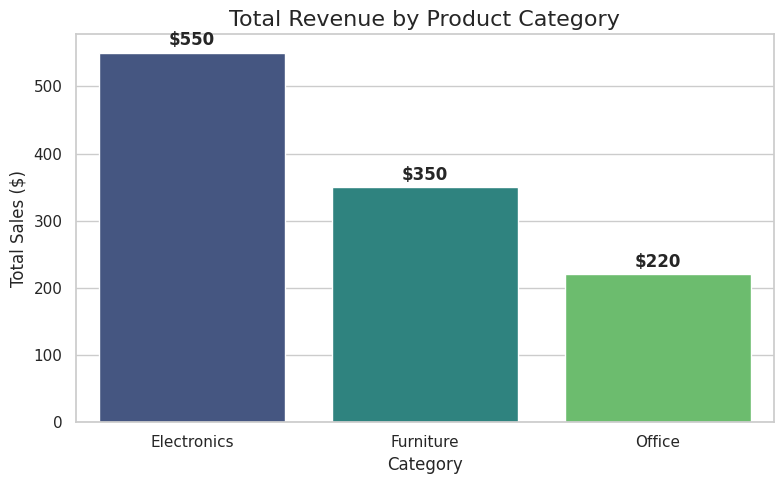

In [ ]:
# Visualization 1: Total Sales by Category
plt.figure(figsize=(8, 5))
sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ax = sns.barplot(x=sales_by_cat.index, y=sales_by_cat.values, palette="viridis")
plt.title('Total Revenue by Product Category', fontsize=16)
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')

# Add value labels
for p in ax.patches:
    ax.annotate(f'${int(p.get_height())}',
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center', xytext=(0, 9),
               textcoords='offset points', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Question 2: Does discounting hurt Profitability?**

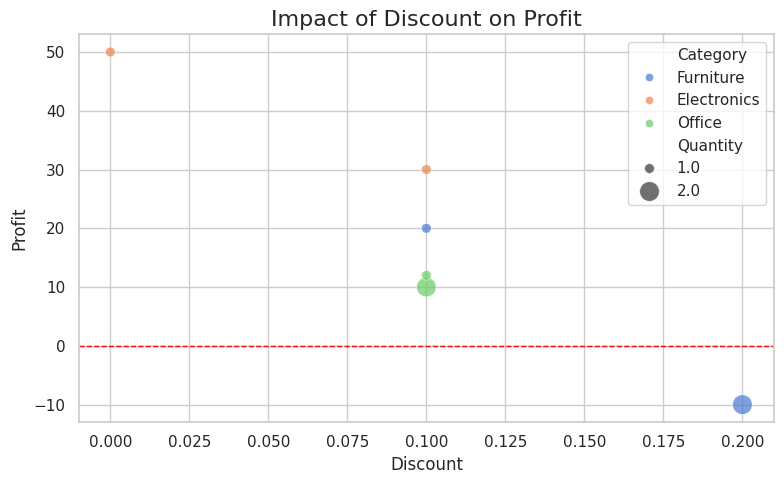

In [ ]:
# Visualization 2: Scatter Plot - Discount vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Quantity', sizes=(50, 200), palette="muted", alpha=0.7)
plt.title('Impact of Discount on Profit', fontsize=16)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Break-even line
plt.tight_layout()
plt.show()

**Storytelling:** This plot reveals a crucial insight. As the Discount (x-axis) increases, Profit (y-axis) drops and often turns negative (below the red line). High discounts are killing our margins!


**Question 3: Which Segment is most valuable?**

<Figure size 800x500 with 0 Axes>

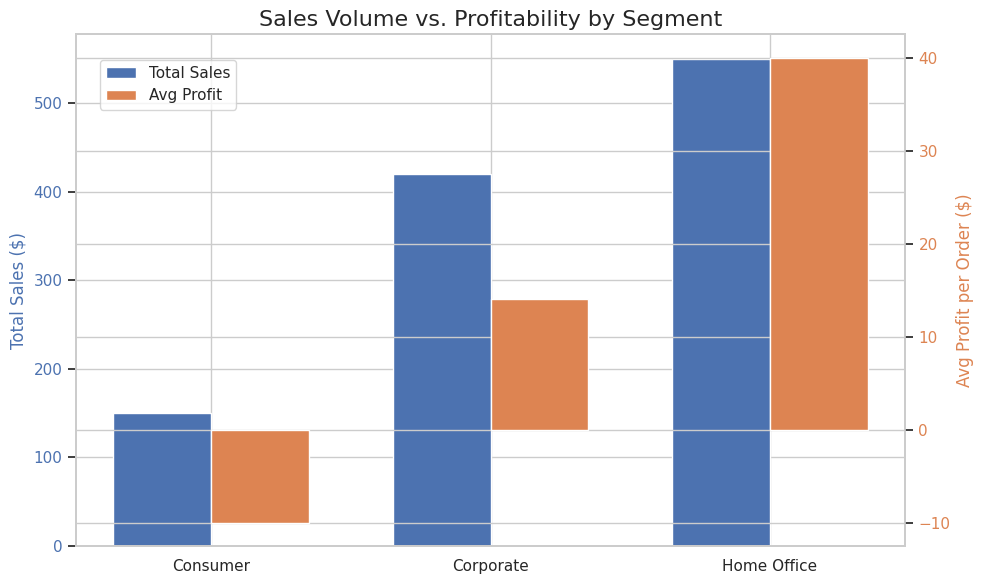

In [ ]:
# Visualization 3: Sales vs Profit by Customer Segment
plt.figure(figsize=(8, 5))
seg_analysis = df.groupby('Customer_Segment').agg({'Sales': 'sum', 'Profit': 'mean'}).reset_index() # Avg Profit per order

# Bar chart with double metrics
x = np.arange(len(seg_analysis))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar for Total Sales
rects1 = ax1.bar(x - width/2, seg_analysis['Sales'], width, label='Total Sales', color='#4C72B0')
ax1.set_ylabel('Total Sales ($)', color='#4C72B0', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Create second axis for Average Profit
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, seg_analysis['Profit'], width, label='Avg Profit', color='#DD8452')
ax2.set_ylabel('Avg Profit per Order ($)', color='#DD8452', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#DD8452')

# Labels
plt.xticks(x, seg_analysis['Customer_Segment'])
plt.title('Sales Volume vs. Profitability by Segment', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

**Summary of Key Findings (The Output):**

Based on the cleaning and visualization, here is the "Story" the data tells:

**Data Quality:** We found duplicate orders and significant errors in sales data (negative values) which were rectified. We also trimmed extreme outliers (80% discounts).

**Revenue:** Electronics is currently leading in raw sales volume.
The "Discount Trap": The Scatter plot clearly shows that offering discounts above 20% results in losses (Negative Profit). This suggests we need to stop offering huge discounts to protect margin.

**Customer Strategy:** Corporate clients bring in the most money, but Home Office clients have the highest average profit per transaction.